# Implementation of SVM on Iris Dataset

### Soft Margin Classification

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)] # petal length, petal width
y = (iris["target"] == 2).astype(np.float64) # Iris-Virginica

svm_clf = Pipeline((
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(C=1, loss="hinge")),
))

In [3]:
# Train and predict
svm_clf.fit(X, y)
svm_clf.predict([[5.5, 1.7]])

array([1.])

In [6]:
svm_clf.predict([[4.5, 1.8]])

array([1.])

### Nonlinear SVM Classification

In [10]:
from sklearn.datasets import make_moons
training_size = 100

X, y = make_moons(n_samples=training_size, noise=0.5)
X = X.reshape(training_size, 2)

class_1 = X[y == 0] #class_1 for y == 0
class_2 = X[y == 1] #class_2 for y == 1

x_class_1 = class_1[:, 0].reshape(len(class_1),1)
y_class_1 = class_1[:, 1].reshape(len(class_1),1)

x_class_2 = class_2[:, 0].reshape(len(class_2),1)
y_class_2 = class_2[:, 1].reshape(len(class_2),1)


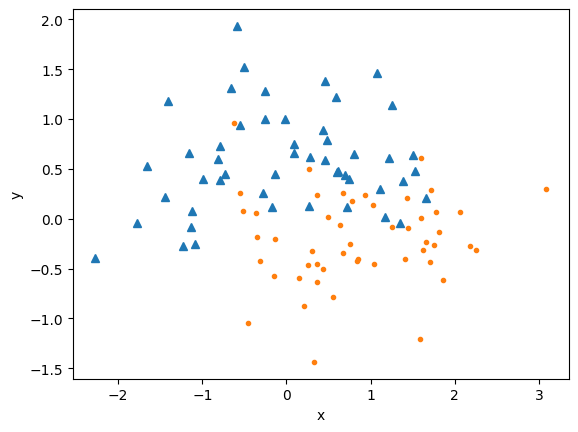

In [11]:
# Plotting the scatter plot
import matplotlib.pyplot as plt

plt.ylabel('y')
plt.xlabel('x')
plt.plot(x_class_1, y_class_1, '^')
plt.plot(x_class_2, y_class_2, '.')
plt.show()

Now let's add another feature $z = x^2 + y^2$

In [12]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)

x_class_1_poly = poly_features.fit_transform(x_class_1)
x_class_2_poly = poly_features.fit_transform(x_class_2)

y_class_1_poly = poly_features.fit_transform(y_class_1)
y_class_2_poly = poly_features.fit_transform(y_class_2)

z_class_1 = (x_class_1_poly[:,1] +
             y_class_1_poly[:,1]).reshape(len(y_class_1_poly), 1)
z_class_2 = (x_class_2_poly[:,1] +
             y_class_2_poly[:, 1]).reshape(len(y_class_2_poly), 1)

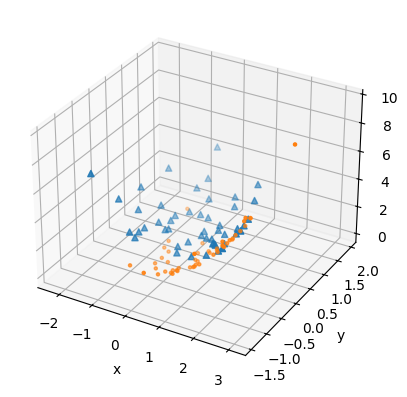

In [13]:
# Plotting the 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_class_1, y_class_1, z_class_1, marker='^')
ax.scatter(x_class_2, y_class_2, z_class_2, marker='.')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()

Using the kernels in scikit-learn

Polynomial

In [17]:
from sklearn.svm import SVC
poly_kernel_svm_clf = Pipeline(
    (("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5)))
)
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

Gaussian RBF

In [18]:
poly_kernel_svm_clf = Pipeline((
    ("scaler", StandardScaler()),
    ("svm_clf", SVC(kernel="rbf", gamma=5, C=0.001))
))
poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=0.001, gamma=5))])

## SVM Regression

In [19]:
from sklearn.svm import LinearSVR

svm_reg = LinearSVR(epsilon=1.5)
svm_reg.fit(X, y)

LinearSVR(epsilon=1.5)

In [20]:
# Using polynomial kernel
from sklearn.svm import SVR

svm_poly_reg = SVR(kernel="poly", degree=2, C=100, epsilon=0.1)
svm_poly_reg.fit(X, y)

SVR(C=100, degree=2, kernel='poly')